In [1]:
import os
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision

In [2]:
import scipy

In [34]:
class OxFordFlowersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, "jpg")
        self.transform = transform

        ## Load Matlab labels
        labels_mat = scipy.io.loadmat(os.path.join(root_dir, "imagelabels.mat"))
        print(labels_mat)
        self.labels = labels_mat["labels"][0] - 1  # Convert to zero-based indexing

    def __len__(self):
        return len(self.labels)  # 8, 189 images
    
    def __getitem__(self, idx):
        # Build the image filename based on the index
        img_name = f"image_{idx+1:05d}.jpg"  # Image filenames are in the format image_00001.jpg, image_00002.jpg, etc.
        img_path = os.path.join(self.img_dir, img_name)

        # load the image
        image = Image.open(img_path)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
 

g = OxFordFlowersDataset(root_dir="flower_data")

print(len(g.labels))

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}
8189


In [35]:
print(g.labels[:10])

[76 76 76 76 76 76 76 76 76 76]


In [36]:
print(f"Min label: {g.labels.min()}")
print(f"Max label: {g.labels.max()}")

Min label: 0
Max label: 101


```python
class OxFordFlowersDataset:
    def __init__(self, data_dir="jpg"):
        self.data_dir = data_dir
        self.image_paths = []
        self.labels = []
        self.load_data()

    def load_data(self):
        import os

        for filename in os.listdir(self.data_dir):
            if filename.endswith(".jpg"):
                self.image_paths.append(os.path.join(self.data_dir, filename))
                label = int(filename.split("_")[0])  # Extract label from filename
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        import cv2

        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        label = self.labels[idx]
        return image, label
```

In [37]:
transform = transforms.Compose([
    transforms.ToTensor()
])

### Possible Probems: 
1. Imagetype error: Python expects Tensors. So your data loader must see tensor not JpegImagePlugging.JpegImageFile
2. RuntimeError: stack expects tensor to be equal size

In [40]:
## without transform
dataset = OxFordFlowersDataset('./flower_data')
for i in [0, 100, 500]:
    img, _ = dataset[i]
    print(f"Image {i} shape: {type(img)}, {img.size}")

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}
Image 0 shape: <class 'PIL.JpegImagePlugin.JpegImageFile'>, (591, 500)
Image 100 shape: <class 'PIL.JpegImagePlugin.JpegImageFile'>, (588, 500)
Image 500 shape: <class 'PIL.JpegImagePlugin.JpegImageFile'>, (667, 500)


In [41]:
dataset = OxFordFlowersDataset('./flower_data')
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
for images, labels in dataloader:
    print(f"Batch of images shape: {images.shape}")
    break

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.JpegImagePlugin.JpegImageFile'>

In [39]:
dataset = OxFordFlowersDataset('./flower_data', transform=transform)
image, label = dataset[0]
print(f"Image shape: {image.shape}, Label: {label}")
image, label = dataset[1]
print(f"Image shape: {image.shape}, Label: {label}")
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for images, labels in dataloader:
    print(f"Batch of images shape: {images.shape}")
    break

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}
Image shape: torch.Size([3, 500, 591]), Label: 76
Image shape: torch.Size([3, 500, 625]), Label: 76


RuntimeError: stack expects each tensor to be equal size, but got [3, 500, 538] at entry 0 and [3, 500, 667] at entry 1

In [48]:
# so what do we do: We resize, and then converts to tensor

dataset = OxFordFlowersDataset('./flower_data')
img, _ = dataset[0]
resized = transforms.Resize(256)(img)
print(f"After resize: {resized.size}")

cropped = transforms.CenterCrop(224)(resized)
print(f"After crop: {cropped.size}")

tensored = transforms.ToTensor()(cropped)
print(tensored.shape)
print(tensored)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}
After resize: (302, 256)
After crop: (224, 224)
torch.Size([3, 224, 224])
tensor([[[0.3804, 0.3765, 0.3765,  ..., 0.5176, 0.5176, 0.5059],
         [0.3843, 0.3765, 0.3765,  ..., 0.5373, 0.5412, 0.5451],
         [0.3961, 0.3882, 0.3804,  ..., 0.5686, 0.5647, 0.5608],
         ...,
         [0.1882, 0.1882, 0.1843,  ..., 0.1686, 0.1608, 0.1529],
         [0.1686, 0.1686, 0.1725,  ..., 0.1804, 0.1882, 0.1843],
         [0.1529, 0.1529, 0.1529,  ..., 0.2314, 0.2392, 0.2275]],

        [[0.5647, 0.5725, 0.5843,  ..., 0.5725, 0.5686, 0.5529],
         [0.5765, 0.5804, 0.5882,  ..., 0.6118, 0.6039, 0.5922],
         [0.5882, 0.5843, 0.5882,  ..., 0.6471, 0.6392, 0.6275],
         ...,
         [0.2314, 0.2314, 0.2314,  ..., 0.1882, 0.1843, 0.1765],
         [0.2118, 0.2118, 0.20

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}


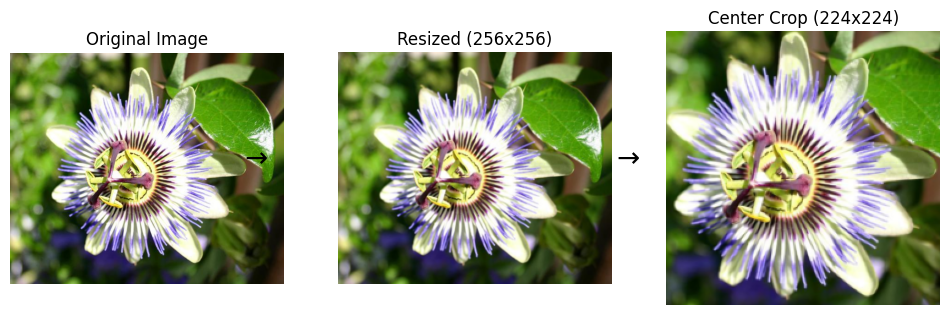

In [44]:
import matplotlib.pyplot as plt

# Load image
dataset = OxFordFlowersDataset('./flower_data')
img, _ = dataset[0]

# Transform steps
resized = transforms.Resize(256)(img)
cropped = transforms.CenterCrop(224)(resized)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Original
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")

# Resized
ax[1].imshow(resized)
ax[1].set_title("Resized (256x256)")
ax[1].axis("off")

# Cropped
ax[2].imshow(cropped)
ax[2].set_title("Center Crop (224x224)")
ax[2].axis("off")

# Add arrows
fig.text(0.32, 0.5, "→", fontsize=20)
fig.text(0.63, 0.5, "→", fontsize=20)

plt.show()

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNX86, Created on: Thu Feb 19 15:43:33 2009', '__version__': '1.0', '__globals__': [], 'labels': array([[77, 77, 77, ..., 62, 62, 62]], shape=(1, 8189), dtype=uint8)}


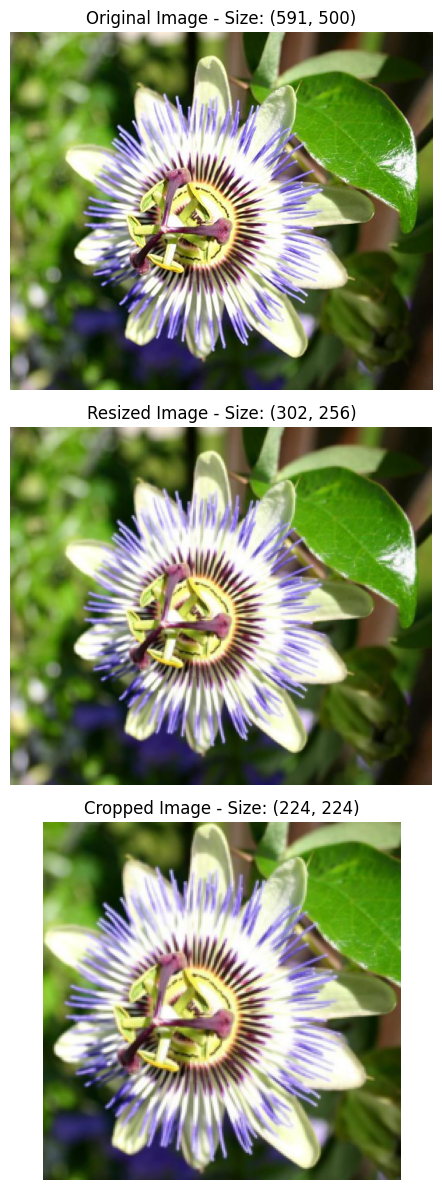

In [ ]:
dataset = OxFordFlowersDataset('./flower_data')
img, _ = dataset[0]

resized = transforms.Resize(256)(img)
cropped = transforms.CenterCrop(224)(resized)

# Plot vertically
plt.figure(figsize=(6, 12))

# Original
plt.subplot(3,1,1)
plt.imshow(img)
plt.title(f"Original Image - Size: {img.size}")
plt.axis("off")

# Resized
plt.subplot(3,1,2)
plt.imshow(resized)
plt.title(f"Resized Image - Size: {resized.size}")
plt.axis("off")

# Cropped
plt.subplot(3,1,3)
plt.imshow(cropped)
plt.title(f"Cropped Image - Size: {cropped.size}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
class OxFordFlowersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, "jpg")
        self.transform = transform

        ## Load Matlab labels
        labels_mat = scipy.io.loadmat(os.path.join(root_dir, "imagelabels.mat"))
        # print(labels_mat)
        self.labels = labels_mat["labels"][0] - 1  # Convert to zero-based indexing

    def __len__(self):
        return len(self.labels)  # 8, 189 images
    
    def __getitem__(self, idx):
        # Build the image filename based on the index
        img_name = f"image_{idx+1:05d}.jpg"  # Image filenames are in the format image_00001.jpg, image_00002.jpg, etc.
        img_path = os.path.join(self.img_dir, img_name)

        # load the image
        image = Image.open(img_path)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
 
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = OxFordFlowersDataset('./flower_data', transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for images, labels in dataloader:
    print(f"Batch of images shape: {images.shape}")
    break

Batch of images shape: torch.Size([4, 3, 224, 224])


#### DataLoader
Split first into Train, validation, and test

In [51]:
dataset = OxFordFlowersDataset(
    './flower_data',
    transform=transform
)

from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Training: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Training: 5732
Validation: 1228
Test: 1229


In [52]:
from torch.utils.data import DataLoader
# Batching
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [53]:
## This loop will go through All your data, one batch at a time
for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}") 
    print(f"Batch of labels shape: {labels.shape}")
    break

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


In [54]:
# or use iter
images, labels = next(iter(train_loader))
print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


#### Batch Number and Epoch

In [55]:
batch_count = 0
total_images = 0

for images, labels in train_loader:
    batch_count += 1
    total_images += len(images)

    if batch_count >= 178:
        print(f"Batch {batch_count}: {len(images)} images")

print(f"\nTotal batches in one epoch: {batch_count}")
print(f"Total images processed in one epoch: {total_images}")

Batch 178: 32 images
Batch 179: 32 images
Batch 180: 4 images

Total batches in one epoch: 180
Total images processed in one epoch: 5732


#### Data Augmentation 

Data augmentation is a technique used in deep learning (especially CNNs) to artificially increase the size and diversity of a dataset by applying transformations to existing data so the model learns more robust and general patterns.

In simple terms:

> Data augmentation = creating new training examples from existing data using transformations

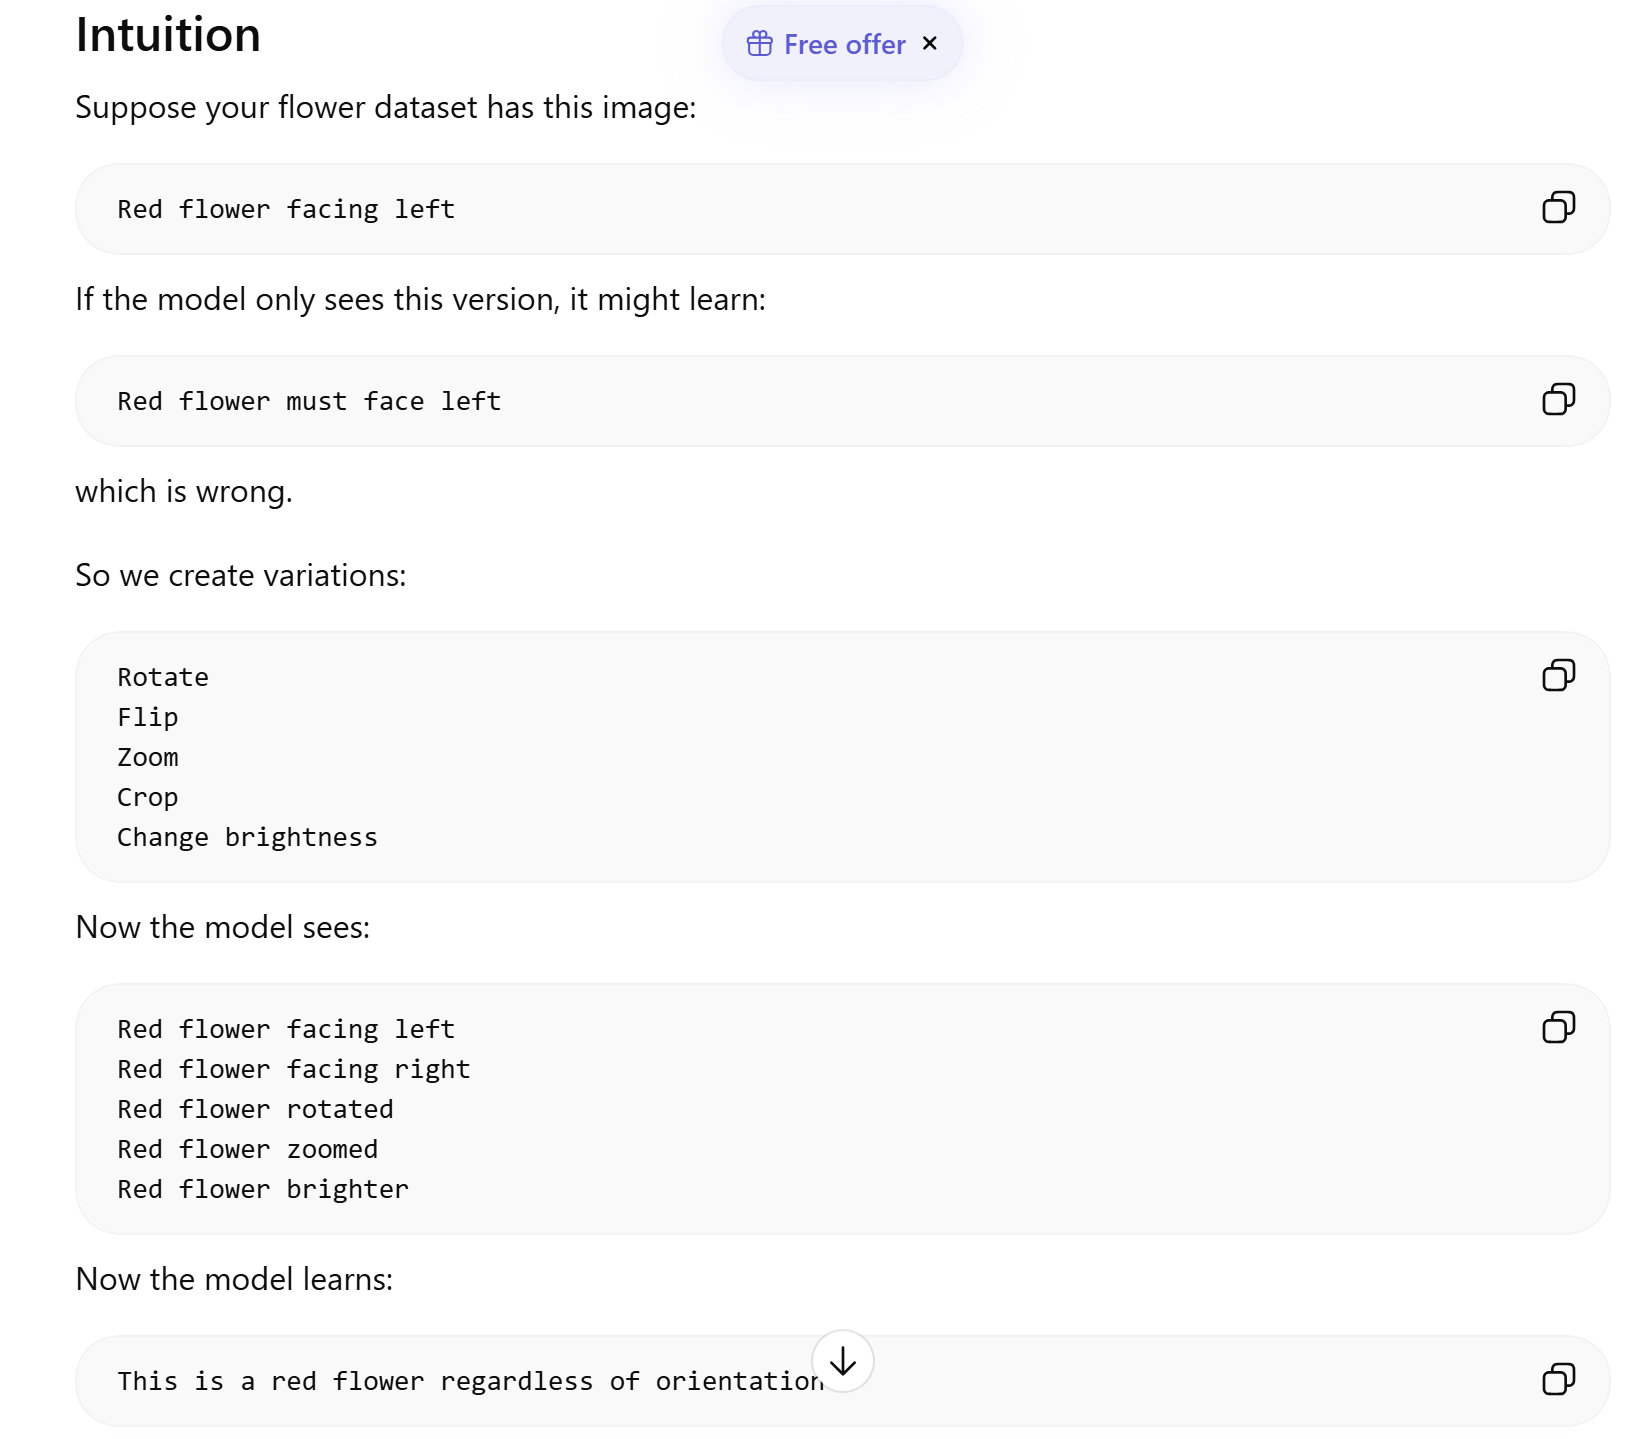

Why Data Augmentation Is Important;
1. Prevents Overfitting
2. Improves generalization
3. Increases Dataset size

In [ ]:
# training transform with random augmentations
train_transform = transforms.Compose([
    # Random augmentations (different each epoch)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    # Standard Preprocessing
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    # Only standard preprocessing, no random augmentations
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

### Bad Image: Tracking errors

In [ ]:
class RobustOxFordFlowersDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, "jpg")
        self.transform = transform

        ## Load Matlab labels
        labels_mat = scipy.io.loadmat(os.path.join(root_dir, "imagelabels.mat"))
        # print(labels_mat)
        self.labels = labels_mat["labels"][0] - 1  # Convert to zero-based indexing
        # Keep track of any errrors  we encounter when loading images
        self.error_log = []

    def __len__(self):
        return len(self.labels)  # 8, 189 images
    
    def __getitem__(self, idx):
        """Load image and label, with error handling"""
        # Build the image filename based on the index
        try:
            img_name = f"image_{idx+1:05d}.jpg"  # Image filenames are in the format image_00001.jpg, image_00002.jpg, etc.
            img_path = os.path.join(self.img_dir, img_name)
            # check if image is valid or corrupted
            image.verify()  # This will raise an exception if the image is corrupted: Verify closes the file
            image = Image.open(img_path)  # Reopen the image after verification 
           
            # skip tiny images
            if image.size[0] < 32 or image.size[1] < 32:
                raise ValueError(f"Image {img_name} is too small: {image.size}")
            # Convert grayscale to RGB if needed
            if image.mode != "RGB":
                image = image.convert("RGB")
            
        except Exception as e:
            self.error_log.append({
                'index': idx,
                'error': str(e),
                "path": img_path if 'img_path' in locals() else "Unknown"
            })
            print(f"Warning: skipping corrupted image {idx}: {e}")
            # Return a default image and label if loading fails
            next_idx = (idx + 1) % len(self.labels)  # Try the next image
            return self.__getitem__(next_idx)  # Recursive call to get the next image and label
        
    def get_error_summary(self):
        """Print a summary of all loading errors encountered"""
        if not self.error_log:
            print("No errors encountered during dataset loading.")
            return
        else:
            print(f"\nEncountered {len(self.error_log)} problematic images during dataset loading:")
            for error in self.error_log[:5]: # Print first 5 errors
                print(f"Index: {error['index']}, Path: {error['path']}, Error: {error['error']}")
            if len(self.error_log) > 5:
                print(f"... and {len(self.error_log) - 5} more errors.")


### How do you know your augmentation is not too much: Look at it
- Build a simple visualization function 

### How do you know your pipeline work during training: Data Tracking

#### Tracking Errors

- Shuffling bugs
- Performance Issues
- Data Imbalance